In [1]:
from utils.gen_paths_multi_bs import gen_paths_multi_bs
from utils.payoff_geo import payoff_geo
from utils.hyperbolic_cross_indices import hyperbolic_cross_indices
from utils.generate_poly_hermite import generate_poly_hermite
import numpy as np

# Hyperbolic cross multi-index set $I$

The hyperbolic cross multi-index set $I$ with maximum order $p \in \mathbb{N}$ is defined by

$$
I :=
\left\{\mathbf{\mathit{\alpha}} = (\alpha_j )_{j=1}^d \in \mathbb{N}^d_0 : \prod^d_{j=1} max(\alpha_j, 1) \leq p\right\},
$$

which has a cardinality $\mathscr{O} (p(ln p)^{d - 1})$.

Using the standard probabilist's Hermite polynomials $H_n(x) = (-1)^ne^{\frac{x^2}{2}}\frac{d^n}{dx^n}e^{-\frac{x^2}{2}}$, we define the nth-order normalised and generalised Hermite polynomial $H_n^{(t)}$ by

$$
H_n^{(t)}:= \frac{H_n(\frac{y}{\sqrt{t}})}{\sqrt{n!}}.
$$

We can now define the Hermite polynomial ansatz space by

$$
P_{I,k} := \text{span}\left\{H_\mathbf{\alpha}^{(t_k)} : \mathbf{\alpha} \in I\right\},
$$

where $H_\mathbf{\alpha}^{(t)}(\mathbf{y}) := \prod_{j=1}^d H_{\alpha _j}^{(t)}(y_i)$.

The function below creates the set $I$.

In [2]:
hyperbolic_cross_indices(2,3)

array([[0, 0],
       [1, 0],
       [2, 0],
       [3, 0],
       [0, 1],
       [0, 2],
       [0, 3],
       [1, 1]])

In [3]:
strike = 100
rate = 0.08
div = 0.0
expiration = 3.0
dim = 2
S0 = np.ones((dim)) * 100
vol = np.diag(np.ones((dim))) * 0.2
cor = np.eye(dim)
numtimestep = 50
callput = 'call'

p = {
    'strike': strike,
    'rate': rate,
    'dividend': div,
    'expiration': expiration,
    'dim': dim,
    'S0': S0,
    'volatility': vol,
    'correlation': cor,
    'numTimeStep': numtimestep,
    'callput': callput
}


# number of trials
M = 100


# Multiasset Black-Scholes

Under the risk-neutral probability $\mathbb{Q}$, the prices of d underlying assets, $\mathbf{S_t} = (S_t^1, \ldots, S_t^d)^\top$, follow the correlated goemetric Brownian motions

$$
d\mathbf{S}_t^i = (r-\delta _i)S_t^idt + \sigma _i S_t^i d\tilde{W}_t^i \quad with \quad S_0^i=s_0^i, \quad i = 1, 2, \ldots, d,
$$


where the $\tilde{W}_t^i$ it are correlated Brownian motions with correlation $\mathbb{E} [d \tilde{W}_i^t d \tilde{W}_j^t] = \rho_{ij} dt$, and $r$, $\delta_i$,and $\sigma_i$ are the riskless interest rate, dividend yields, and volatility parameters, respectively. We denote the correlation matrix by $P = (\rho_{ij} )_{d\times d}$, the volatility matrix by $\Sigma$  (which is adiagonal matrix with volatility $\sigma_i$ on the diagonal), and write the dividend yields as a vector $\mathbf{\delta}  = [\delta_1, \ldots , \delta_d]^\top$. Using the spectral decomposition $\Sigma P \Sigma^\top  = Q\Lambda Q^\top$ , the rotated log-price $\mathbf{\tilde{X}}_t := Q^\top  \text{ln}(\mathbf{S}_t./\mathbf{s}_0)$ satisfies an independent Gaussian distribution
$$
\mathbf{\tilde{X}}_t \sim  \mathscr{N} \biggl( Q^\top \biggl( r - \mathbf{\mathit{\delta}} - \frac{1}{2} \Sigma^2\mathbf{1} \biggr) t, \Lambda t\biggr) .
$$

Let $\mathbf{\mathit{\mu}}  = Q^\top (r - \mathbf{\mathit{\delta}} - \frac{1}{2} \Sigma^2\mathbf{1} )$ and $\lambda_i$ be the $i$ th diagonal element of $\Lambda$. Here we have used that the correlation matrix is diagonal, if this is not the case, we have to replace $\Sigma^2\mathbf{1}$ with $\text{diag}(\Sigma P \Sigma^\top)$.

This gives a transformation between underlying asset prices $\mathbf{S}_t$ and independent Brownian motions $\mathbf{W}_t = [W_t^1 , \ldots , W_t^d ]^\top$ ,i.e., 
$$
\mathbf{S}_t = \mathbf{s}_0 \odot \text{exp}\Bigl( Q\Bigl( \mathbf{\mathit{\mu}} t + \sqrt{\Lambda} \mathbf{W}_t\Bigr) \Bigr),
$$
where $\odot$  denotes componentwise product.
    
The function called below takes in the parameters of the Multiasset Black-Scholes model and generates multiple random paths for both the Brownian Motion, $\mathbf{W}_t$, and the price paths, $\mathbf{S}_t$.

In [4]:
W, S = gen_paths_multi_bs(p, M)

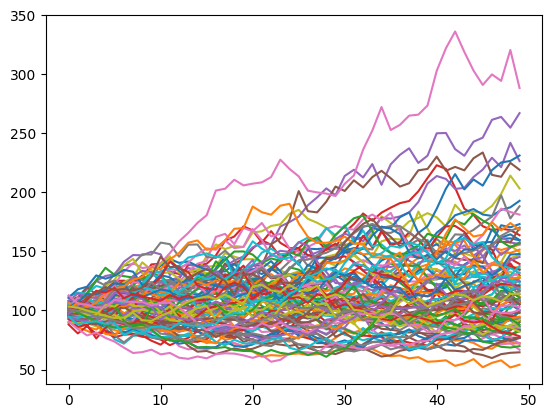

In [5]:
import matplotlib.pyplot as plt

plt.plot(S[:, 0, :].T)
plt.show()

# Value matrix

This function computes the present value of a geometric basket option. It is fed an $(M, d, N)$ tensor, where there are $M$ stochastic price paths, $d$ assets, and $N$ time steps. For each path and time point, the function calculates the value of a geometric basket option, which is defined by

$$
\text{Basket}_k^m = \left(\prod _{i=1}^dS_{k, i}^m\right)^{1/d}.
$$

The output is an $(M, N)$ matrix. This funcion is only used for the geometric basket testing. Similar functions can be made to estimate prices for different options.

In [6]:
K = p['strike']
r = p['rate']
dt = p['expiration'] / p['numTimeStep']
callput = p['callput']

value_matrix = payoff_geo(S, K, r, dt, callput)
print(value_matrix.shape)

(100, 50)


# Generate $\mathbf{\Phi}_k$ = basis matrix($\mathbf{W}_k, I)$

In Algortihm 4.1, we require a basis matrix to be built for every time step. This matrix will be further modified by implementing gradient information by Algorithm 4.2.

For each $\mathbf{\alpha} \in I$, we have a basis polynomial $H_\mathbf{\alpha}^{(t)}(\mathbf{W}_{t})$, where $\mathbf{W}_t$ is the matrix of Brownian noise for dimension at time $t$, with elements $w_{ij}$, where $i$ is path index, and $j$ is the dimension (asset number).

Within `generate_poly_hermite()` we call on `generate_poly_basis_1d` for each dimension.

`generate_poly_basis_1d` creates a matrix 

\begin{equation}
A_j = 
\begin{bmatrix}
    H_0(w_0^j) & H_1(w_0^j) & \dots & H_p(w_0^j) \\
    H_0(w_1^j) & H_1(w_1^j) & \dots & H_p(w_1^j) \\
    \vdots & \ddots & & \vdots \\
    H_0(w_m^j) & H_1(w_m^j) & \dots & H_p(w_m^j)
\end{bmatrix},
\end{equation}

for each dimension (asset) $j$, where $p$ is the order of the multi-index set.

`generate_poly_hermite()` generates a single matrix for each dimension and then creates the basis matrix.

The function builts a basis vector from all of the different $A_j$ matrices for each $\mathbf{\alpha} \in I$, this forms our basis matrix $\Phi$. For example, if we have, for $d=3$, then the column of the index matrix corresponding to $\alpha = [3, 0, 1]^\top$, will look like

\begin{equation}
\Phi_\mathbf{\alpha} = 
\begin{bmatrix}
    H_3(w_0^1)H_0(w_0^2)H_1(w_0^3) \\
    H_3(w_1^1)H_0(w_1^2)H_1(w_1^3) \\
    \vdots \\
    H_3(w_m^1)H_0(w_m^2)H_1(w_m^3) \\
\end{bmatrix}.
\end{equation}


In [10]:
I = hyperbolic_cross_indices(2, 5)
A = generate_poly_hermite('hermite', I, W[:,:,2], 0.6)
print(f'Shape of A: {A.shape}')

Shape of A: (100, 14)


# Heston Model

The next functions are used to run the G-LSM algorithm with the Heston model instead of the Black-Scholes model. We only model one asset here.

In this model, we say the volatility of the price path is also a stochastic process. In the paper, the authours used a Hermite basis for the price, but a Chebyshev basis for the volatility.

The function `gen_poly_basis_grad` is helper functions which returns the basis matrices, along with their derivatives to be used in the G-LSM code which estimates the price of an option in the Heston model. This function is used because now we have different derivatives to do, rather than just the Hermite derivatives, which can be done on the fly due to the properties of Hermite polynomials. The derivative of a Chebyshev polynomial looks a lot more complicated. In code it doesn't look too bad, but these functions just clean things up